<a href="https://colab.research.google.com/github/Dhanush7-tech/Deep-Learning-LAB/blob/main/Lab-5/DeepLearning_Lab_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
from torch.utils.data import DataLoader, random_split
from torchvision import transforms
from torchvision.datasets import OxfordIIITPet

# ImageNet mean/std — required since MobileNetV2 is pretrained on ImageNet
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# Same normalization for val/test — no augmentation, to keep eval consistent
eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

In [2]:
full_dataset = OxfordIIITPet(
    root="./data",
    split="trainval",
    target_types="category",
    download=True,
    transform=eval_transform  # placeholder; we'll assign per-split transforms below
)

test_dataset = OxfordIIITPet(
    root="./data",
    split="test",
    target_types="category",
    download=True,
    transform=eval_transform
)

print(f"Trainval size: {len(full_dataset)}, Test size: {len(test_dataset)}")

100%|██████████| 792M/792M [00:36<00:00, 21.8MB/s]
100%|██████████| 19.2M/19.2M [00:01<00:00, 12.8MB/s]


Trainval size: 3680, Test size: 3669


In [3]:
val_ratio = 0.15
val_size = int(len(full_dataset) * val_ratio)
train_size = len(full_dataset) - val_size

generator = torch.Generator().manual_seed(42)  # reproducibility
train_subset, val_subset = random_split(full_dataset, [train_size, val_size], generator=generator)

print(f"Train: {len(train_subset)}, Val: {len(val_subset)}, Test: {len(test_dataset)}")

Train: 3128, Val: 552, Test: 3669


In [4]:
BATCH_SIZE = 32

train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

In [5]:
import torch.nn as nn
from torchvision.models import mobilenet_v2, MobileNet_V2_Weights

NUM_CLASSES = 37

def build_model(init_method="default"):
    model = mobilenet_v2(weights=MobileNet_V2_Weights.IMAGENET1K_V1)

    # Freeze pretrained backbone — only the head's init strategy varies
    for param in model.features.parameters():
        param.requires_grad = False

    in_features = model.classifier[1].in_features
    new_head = nn.Linear(in_features, NUM_CLASSES)

    # Apply the requested initialization to the new head
    if init_method == "zero":
        nn.init.zeros_(new_head.weight)
        nn.init.zeros_(new_head.bias)
    elif init_method == "random":
        nn.init.normal_(new_head.weight, mean=0.0, std=0.01)
        nn.init.zeros_(new_head.bias)
    elif init_method == "xavier":
        nn.init.xavier_uniform_(new_head.weight)
        nn.init.zeros_(new_head.bias)
    elif init_method == "he":
        nn.init.kaiming_uniform_(new_head.weight, nonlinearity="relu")
        nn.init.zeros_(new_head.bias)
    else:
        raise ValueError(f"Unknown init method: {init_method}")

    model.classifier[1] = new_head
    return model

In [6]:
import torch.optim as optim

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
EPOCHS = 10

def train_one_config(init_method):
    model = build_model(init_method).to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.classifier[1].parameters(), lr=1e-3)

    history = {"train_loss": [], "val_acc": []}

    for epoch in range(EPOCHS):
        # --- Train ---
        model.train()
        running_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * images.size(0)

        epoch_train_loss = running_loss / len(train_subset)
        history["train_loss"].append(epoch_train_loss)

        # --- Validate ---
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(DEVICE), labels.to(DEVICE)
                outputs = model(images)
                preds = outputs.argmax(dim=1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)

        epoch_val_acc = 100.0 * correct / total
        history["val_acc"].append(epoch_val_acc)

        print(f"[{init_method}] Epoch {epoch+1}/{EPOCHS} | "
              f"Train Loss: {epoch_train_loss:.4f} | Val Acc: {epoch_val_acc:.2f}%")

    return history

In [7]:
init_methods = ["zero", "random", "xavier", "he"]
results = {}

for method in init_methods:
    print(f"\n{'='*50}\nRunning: {method}\n{'='*50}")
    results[method] = train_one_config(method)




Running: zero
Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 165MB/s]


[zero] Epoch 1/10 | Train Loss: 1.6377 | Val Acc: 84.06%
[zero] Epoch 2/10 | Train Loss: 0.5862 | Val Acc: 85.51%
[zero] Epoch 3/10 | Train Loss: 0.4090 | Val Acc: 88.22%
[zero] Epoch 4/10 | Train Loss: 0.3226 | Val Acc: 87.68%
[zero] Epoch 5/10 | Train Loss: 0.2740 | Val Acc: 87.32%
[zero] Epoch 6/10 | Train Loss: 0.2197 | Val Acc: 88.77%
[zero] Epoch 7/10 | Train Loss: 0.1993 | Val Acc: 88.77%
[zero] Epoch 8/10 | Train Loss: 0.1811 | Val Acc: 88.41%
[zero] Epoch 9/10 | Train Loss: 0.1672 | Val Acc: 86.78%
[zero] Epoch 10/10 | Train Loss: 0.1458 | Val Acc: 88.59%

Running: random
[random] Epoch 1/10 | Train Loss: 1.6914 | Val Acc: 86.41%
[random] Epoch 2/10 | Train Loss: 0.5844 | Val Acc: 86.41%
[random] Epoch 3/10 | Train Loss: 0.4230 | Val Acc: 88.04%
[random] Epoch 4/10 | Train Loss: 0.3277 | Val Acc: 88.04%
[random] Epoch 5/10 | Train Loss: 0.2842 | Val Acc: 88.04%
[random] Epoch 6/10 | Train Loss: 0.2322 | Val Acc: 87.32%
[random] Epoch 7/10 | Train Loss: 0.2067 | Val Acc: 89.49%

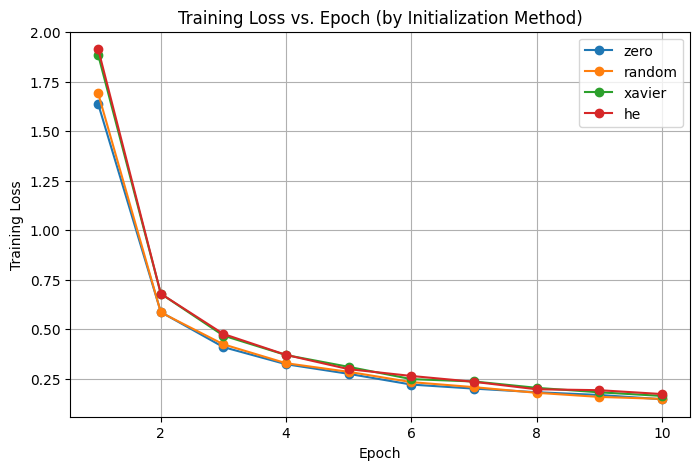

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
for method in init_methods:
    plt.plot(range(1, EPOCHS + 1), results[method]["train_loss"], marker='o', label=method)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss vs. Epoch (by Initialization Method)")
plt.legend()
plt.grid(True)
plt.savefig("plot1_train_loss.png", dpi=150, bbox_inches="tight")
plt.show()

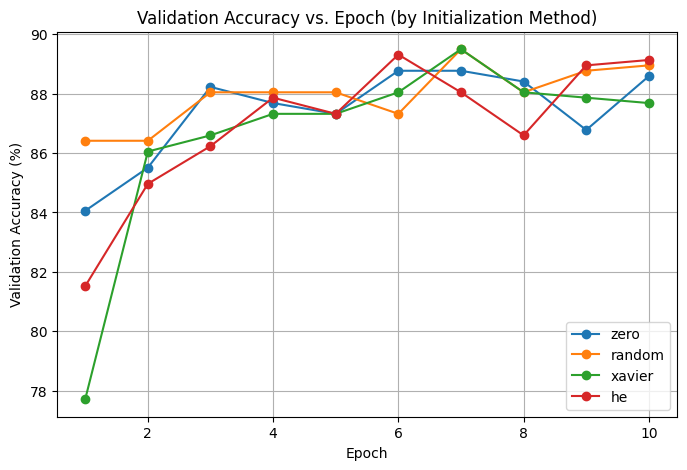

In [9]:
plt.figure(figsize=(8, 5))
for method in init_methods:
    plt.plot(range(1, EPOCHS + 1), results[method]["val_acc"], marker='o', label=method)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy (%)")
plt.title("Validation Accuracy vs. Epoch (by Initialization Method)")
plt.legend()
plt.grid(True)
plt.savefig("plot2_val_accuracy.png", dpi=150, bbox_inches="tight")
plt.show()

In [10]:
def build_model_reg(reg_method="none", dropout_p=0.5, weight_decay=1e-4):
    model = mobilenet_v2(weights=MobileNet_V2_Weights.IMAGENET1K_V1)

    for param in model.features.parameters():
        param.requires_grad = False

    in_features = model.classifier[1].in_features

    if reg_method == "dropout":
        # Keep dropout, but set explicit p (default MobileNetV2 head already has Dropout(0.2))
        head = nn.Sequential(
            nn.Dropout(p=dropout_p),
            nn.Linear(in_features, NUM_CLASSES)
        )
    elif reg_method == "batchnorm":
        head = nn.Sequential(
            nn.Linear(in_features, NUM_CLASSES),
            nn.BatchNorm1d(NUM_CLASSES)
        )
    else:
        # "none" and "l2" use the same plain head — L2 is applied via optimizer weight_decay instead
        head = nn.Linear(in_features, NUM_CLASSES)

    # Apply He init consistently across all four, so regularization is the only variable
    for m in head.modules():
        if isinstance(m, nn.Linear):
            nn.init.kaiming_uniform_(m.weight, nonlinearity="relu")
            nn.init.zeros_(m.bias)

    model.classifier[1] = head
    return model

In [11]:
def train_one_reg_config(reg_method):
    model = build_model_reg(reg_method).to(DEVICE)
    criterion = nn.CrossEntropyLoss()

    wd = 1e-4 if reg_method == "l2" else 0.0
    optimizer = optim.Adam(model.classifier[1].parameters(), lr=1e-3, weight_decay=wd)

    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    for epoch in range(EPOCHS):
        # --- Train ---
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            correct += (outputs.argmax(dim=1) == labels).sum().item()
            total += labels.size(0)

        history["train_loss"].append(running_loss / total)
        history["train_acc"].append(100.0 * correct / total)

        # --- Validate ---
        model.eval()
        val_running_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(DEVICE), labels.to(DEVICE)
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_running_loss += loss.item() * images.size(0)
                val_correct += (outputs.argmax(dim=1) == labels).sum().item()
                val_total += labels.size(0)

        history["val_loss"].append(val_running_loss / val_total)
        history["val_acc"].append(100.0 * val_correct / val_total)

        print(f"[{reg_method}] Epoch {epoch+1}/{EPOCHS} | "
              f"Train Loss: {history['train_loss'][-1]:.4f}, Train Acc: {history['train_acc'][-1]:.2f}% | "
              f"Val Loss: {history['val_loss'][-1]:.4f}, Val Acc: {history['val_acc'][-1]:.2f}%")

    return history

In [12]:
reg_methods = ["none", "l2", "dropout", "batchnorm"]
reg_results = {}

for method in reg_methods:
    print(f"\n{'='*50}\nRunning: {method}\n{'='*50}")
    reg_results[method] = train_one_reg_config(method)


Running: none
[none] Epoch 1/10 | Train Loss: 1.9165, Train Acc: 49.87% | Val Loss: 0.8234, Val Acc: 79.17%
[none] Epoch 2/10 | Train Loss: 0.7010, Train Acc: 81.59% | Val Loss: 0.5729, Val Acc: 85.14%
[none] Epoch 3/10 | Train Loss: 0.4736, Train Acc: 87.69% | Val Loss: 0.4724, Val Acc: 85.14%
[none] Epoch 4/10 | Train Loss: 0.3779, Train Acc: 89.39% | Val Loss: 0.4231, Val Acc: 87.68%
[none] Epoch 5/10 | Train Loss: 0.3165, Train Acc: 91.78% | Val Loss: 0.3952, Val Acc: 87.14%
[none] Epoch 6/10 | Train Loss: 0.2704, Train Acc: 92.10% | Val Loss: 0.4010, Val Acc: 87.86%
[none] Epoch 7/10 | Train Loss: 0.2315, Train Acc: 93.86% | Val Loss: 0.4005, Val Acc: 88.04%
[none] Epoch 8/10 | Train Loss: 0.2180, Train Acc: 94.57% | Val Loss: 0.3707, Val Acc: 88.77%
[none] Epoch 9/10 | Train Loss: 0.1829, Train Acc: 95.30% | Val Loss: 0.3718, Val Acc: 88.22%
[none] Epoch 10/10 | Train Loss: 0.1578, Train Acc: 95.72% | Val Loss: 0.3965, Val Acc: 86.96%

Running: l2
[l2] Epoch 1/10 | Train Loss: 1

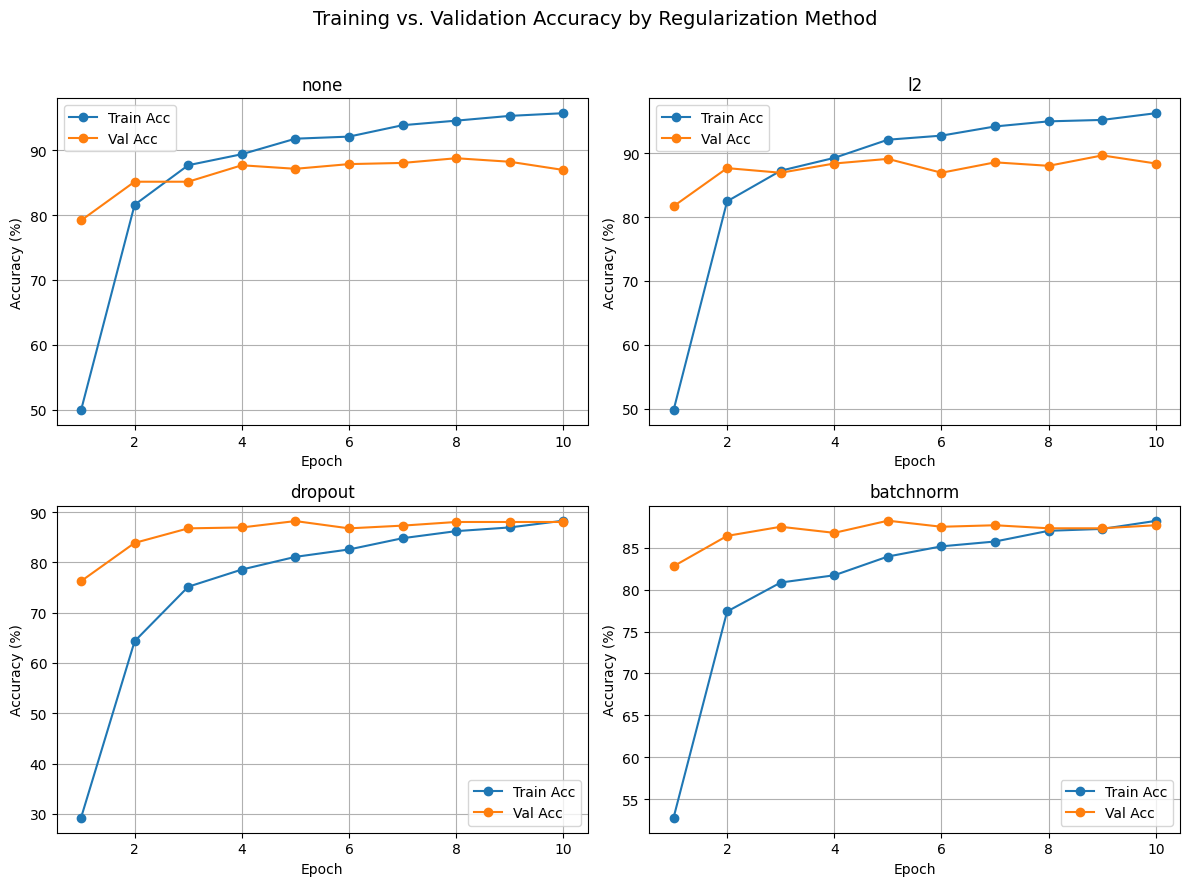

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.flatten()

for ax, method in zip(axes, reg_methods):
    epochs_range = range(1, EPOCHS + 1)
    ax.plot(epochs_range, reg_results[method]["train_acc"], marker='o', label="Train Acc")
    ax.plot(epochs_range, reg_results[method]["val_acc"], marker='o', label="Val Acc")
    ax.set_title(f"{method}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy (%)")
    ax.legend()
    ax.grid(True)

fig.suptitle("Training vs. Validation Accuracy by Regularization Method", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("plot3_train_val_accuracy.png", dpi=150, bbox_inches="tight")
plt.show()

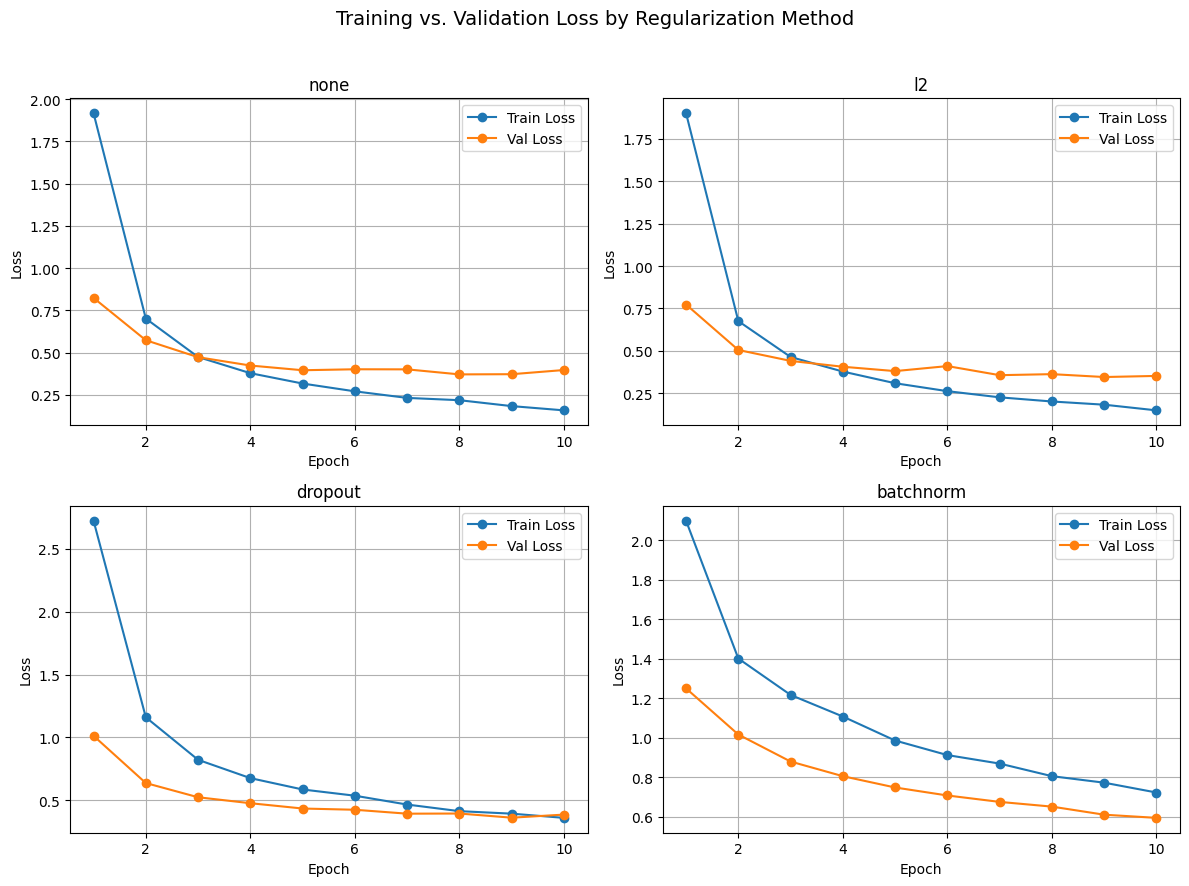

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.flatten()

for ax, method in zip(axes, reg_methods):
    epochs_range = range(1, EPOCHS + 1)
    ax.plot(epochs_range, reg_results[method]["train_loss"], marker='o', label="Train Loss")
    ax.plot(epochs_range, reg_results[method]["val_loss"], marker='o', label="Val Loss")
    ax.set_title(f"{method}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend()
    ax.grid(True)

fig.suptitle("Training vs. Validation Loss by Regularization Method", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("plot4_train_val_loss.png", dpi=150, bbox_inches="tight")
plt.show()

In [15]:
print(f"{'Method':<12} {'Final Train Acc':<18} {'Final Val Acc':<16} {'Gap (Train-Val)':<16}")
for method in reg_methods:
    train_acc = reg_results[method]["train_acc"][-1]
    val_acc = reg_results[method]["val_acc"][-1]
    gap = train_acc - val_acc
    print(f"{method:<12} {train_acc:<18.2f} {val_acc:<16.2f} {gap:<16.2f}")

Method       Final Train Acc    Final Val Acc    Gap (Train-Val) 
none         95.72              86.96            8.76            
l2           96.29              88.41            7.89            
dropout      88.30              88.04            0.26            
batchnorm    88.20              87.68            0.52            


In [16]:
def find_overfitting_onset(history):
    train_loss = history["train_loss"]
    val_loss = history["val_loss"]

    onset_epoch = None
    for epoch in range(1, len(val_loss)):
        train_decreasing = train_loss[epoch] < train_loss[epoch - 1]
        val_increasing = val_loss[epoch] > val_loss[epoch - 1]
        if train_decreasing and val_increasing:
            onset_epoch = epoch + 1  # 1-indexed epoch number
            break  # first occurrence

    return onset_epoch

print(f"{'Method':<12} {'Overfitting onset epoch':<25} {'Min Val Loss Epoch':<20}")
for method in reg_methods:
    onset = find_overfitting_onset(reg_results[method])
    min_val_loss_epoch = reg_results[method]["val_loss"].index(min(reg_results[method]["val_loss"])) + 1
    onset_str = str(onset) if onset else "None detected"
    print(f"{method:<12} {onset_str:<25} {min_val_loss_epoch:<20}")

Method       Overfitting onset epoch   Min Val Loss Epoch  
none         6                         8                   
l2           6                         9                   
dropout      8                         9                   
batchnorm    None detected             10                  


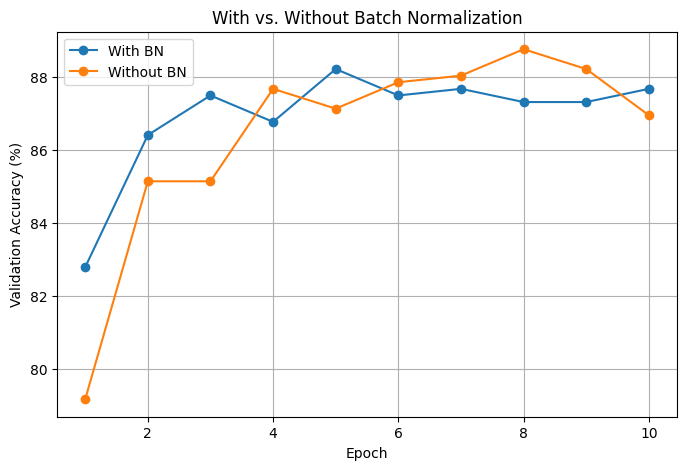

In [17]:
plt.figure(figsize=(8, 5))

epochs_range = range(1, EPOCHS + 1)
plt.plot(epochs_range, reg_results["batchnorm"]["val_acc"], marker='o', label="With BN")
plt.plot(epochs_range, reg_results["none"]["val_acc"], marker='o', label="Without BN")

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy (%)")
plt.title("With vs. Without Batch Normalization")
plt.legend()
plt.grid(True)
plt.savefig("plot5_bn_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

In [18]:
def build_model_opt():
    model = mobilenet_v2(weights=MobileNet_V2_Weights.IMAGENET1K_V1)

    for param in model.features.parameters():
        param.requires_grad = False

    in_features = model.classifier[1].in_features
    head = nn.Linear(in_features, NUM_CLASSES)

    nn.init.kaiming_uniform_(head.weight, nonlinearity="relu")
    nn.init.zeros_(head.bias)

    model.classifier[1] = head
    return model

In [19]:
def get_optimizer(name, params):
    if name == "sgd":
        return optim.SGD(params, lr=1e-2)
    elif name == "momentum":
        return optim.SGD(params, lr=1e-2, momentum=0.9)
    elif name == "rmsprop":
        return optim.RMSprop(params, lr=1e-3)
    elif name == "adam":
        return optim.Adam(params, lr=1e-3)
    else:
        raise ValueError(f"Unknown optimizer: {name}")

In [20]:
def train_one_optimizer(opt_name):
    model = build_model_opt().to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = get_optimizer(opt_name, model.classifier[1].parameters())

    history = {"train_loss": [], "val_acc": []}

    for epoch in range(EPOCHS):
        model.train()
        running_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * images.size(0)

        history["train_loss"].append(running_loss / len(train_subset))

        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(DEVICE), labels.to(DEVICE)
                outputs = model(images)
                correct += (outputs.argmax(dim=1) == labels).sum().item()
                total += labels.size(0)

        history["val_acc"].append(100.0 * correct / total)

        print(f"[{opt_name}] Epoch {epoch+1}/{EPOCHS} | "
              f"Train Loss: {history['train_loss'][-1]:.4f} | Val Acc: {history['val_acc'][-1]:.2f}%")

    return history

In [21]:
optimizer_names = ["sgd", "momentum", "rmsprop", "adam"]
opt_results = {}

for name in optimizer_names:
    print(f"\n{'='*50}\nRunning: {name}\n{'='*50}")
    opt_results[name] = train_one_optimizer(name)


Running: sgd
[sgd] Epoch 1/10 | Train Loss: 2.9962 | Val Acc: 55.07%
[sgd] Epoch 2/10 | Train Loss: 1.8336 | Val Acc: 74.46%
[sgd] Epoch 3/10 | Train Loss: 1.3115 | Val Acc: 80.43%
[sgd] Epoch 4/10 | Train Loss: 1.0433 | Val Acc: 82.61%
[sgd] Epoch 5/10 | Train Loss: 0.8799 | Val Acc: 84.96%
[sgd] Epoch 6/10 | Train Loss: 0.7681 | Val Acc: 85.14%
[sgd] Epoch 7/10 | Train Loss: 0.6858 | Val Acc: 86.23%
[sgd] Epoch 8/10 | Train Loss: 0.6234 | Val Acc: 87.14%
[sgd] Epoch 9/10 | Train Loss: 0.5800 | Val Acc: 86.59%
[sgd] Epoch 10/10 | Train Loss: 0.5385 | Val Acc: 88.59%

Running: momentum
[momentum] Epoch 1/10 | Train Loss: 1.5012 | Val Acc: 83.51%
[momentum] Epoch 2/10 | Train Loss: 0.4992 | Val Acc: 86.96%
[momentum] Epoch 3/10 | Train Loss: 0.3661 | Val Acc: 85.69%
[momentum] Epoch 4/10 | Train Loss: 0.3040 | Val Acc: 87.32%
[momentum] Epoch 5/10 | Train Loss: 0.2519 | Val Acc: 86.96%
[momentum] Epoch 6/10 | Train Loss: 0.2151 | Val Acc: 87.68%
[momentum] Epoch 7/10 | Train Loss: 0.20

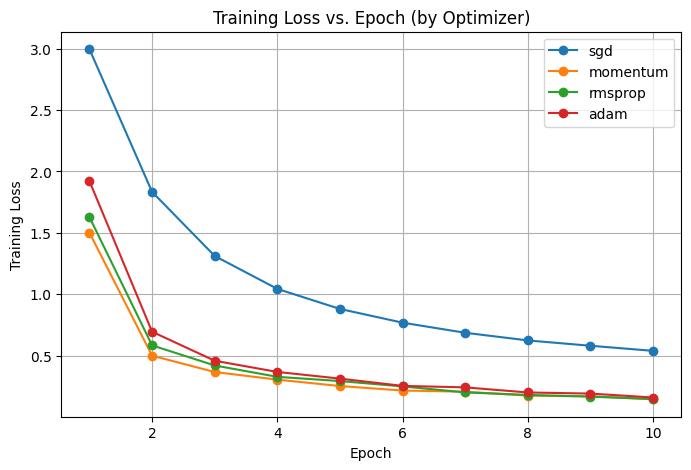

In [22]:
plt.figure(figsize=(8, 5))
for name in optimizer_names:
    plt.plot(range(1, EPOCHS + 1), opt_results[name]["train_loss"], marker='o', label=name)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss vs. Epoch (by Optimizer)")
plt.legend()
plt.grid(True)
plt.savefig("plot6_optimizer_loss.png", dpi=150, bbox_inches="tight")
plt.show()

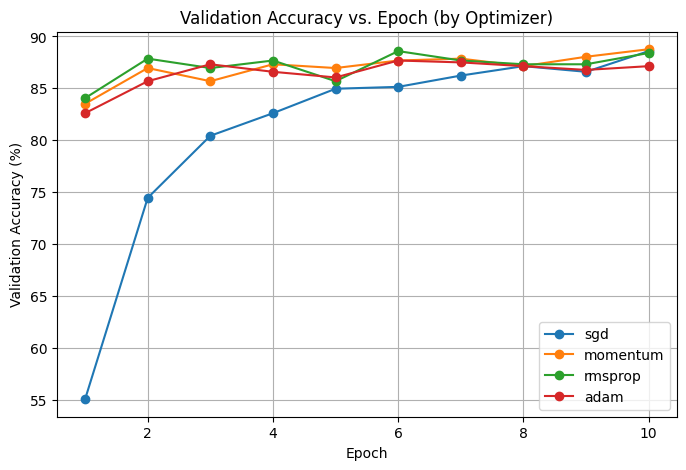

In [23]:
plt.figure(figsize=(8, 5))
for name in optimizer_names:
    plt.plot(range(1, EPOCHS + 1), opt_results[name]["val_acc"], marker='o', label=name)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy (%)")
plt.title("Validation Accuracy vs. Epoch (by Optimizer)")
plt.legend()
plt.grid(True)
plt.savefig("plot7_optimizer_val_accuracy.png", dpi=150, bbox_inches="tight")
plt.show()

In [24]:
baseline_config = {
    "lr": 0.001,
    "batch_size": 32,
    "dropout": 0.25,
    "optimizer": "adam",
    "fine_tune_lr": 1e-5,
    "frozen": "frozen_base",  # or "partial_unfreeze"
}

In [25]:
EPOCHS = 5

In [26]:
def build_model_tune(dropout_rate=0.25, frozen="frozen_base"):
    model = mobilenet_v2(weights=MobileNet_V2_Weights.IMAGENET1K_V1)

    if frozen == "frozen_base":
        for param in model.features.parameters():
            param.requires_grad = False
    elif frozen == "partial_unfreeze":
        # Freeze all, then unfreeze the last few feature blocks for fine-tuning
        for param in model.features.parameters():
            param.requires_grad = False
        for param in model.features[-3:].parameters():
            param.requires_grad = True

    in_features = model.classifier[1].in_features
    head = nn.Sequential(
        nn.Dropout(p=dropout_rate),
        nn.Linear(in_features, NUM_CLASSES)
    )
    nn.init.kaiming_uniform_(head[1].weight, nonlinearity="relu")
    nn.init.zeros_(head[1].bias)
    model.classifier[1] = head

    return model

In [27]:
def get_tuned_optimizer(model, opt_name, lr, fine_tune_lr, frozen):
    if frozen == "partial_unfreeze":
        # Two param groups: head trains at lr, unfrozen backbone at fine_tune_lr
        param_groups = [
            {"params": model.classifier[1].parameters(), "lr": lr},
            {"params": model.features[-3:].parameters(), "lr": fine_tune_lr},
        ]
    else:
        param_groups = [{"params": model.classifier[1].parameters(), "lr": lr}]

    if opt_name == "sgd":
        return optim.SGD(param_groups, momentum=0.9)
    elif opt_name == "adam":
        return optim.Adam(param_groups)

In [30]:
def run_config(config, batch_size=None, tag="config"):
    bs = batch_size or config["batch_size"]
    train_loader_local = DataLoader(train_subset, batch_size=bs, shuffle=True, num_workers=2)
    val_loader_local = DataLoader(val_subset, batch_size=bs, shuffle=False, num_workers=2)

    model = build_model_tune(config["dropout"], config["frozen"]).to(DEVICE)
    optimizer = get_tuned_optimizer(model, config["optimizer"], config["lr"],
                                     config["fine_tune_lr"], config["frozen"])
    criterion = nn.CrossEntropyLoss()

    history = {"train_loss": [], "val_acc": []}
    for epoch in range(EPOCHS):
        model.train()
        running_loss = 0.0
        for images, labels in train_loader_local:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * images.size(0)
        history["train_loss"].append(running_loss / len(train_subset))

        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for images, labels in val_loader_local:
                images, labels = images.to(DEVICE), labels.to(DEVICE)
                outputs = model(images)
                correct += (outputs.argmax(dim=1) == labels).sum().item()
                total += labels.size(0)
        history["val_acc"].append(100.0 * correct / total)

        print(f"[{tag}] Epoch {epoch+1}/{EPOCHS} | "
              f"Train Loss: {history['train_loss'][-1]:.4f} | Val Acc: {history['val_acc'][-1]:.2f}%")

    return history

In [32]:
sweep_results = {}

for lr in [0.001, 0.0001]:
    cfg = {**baseline_config, "lr": lr}
    sweep_results[f"lr_{lr}"] = run_config(cfg, tag=f"lr_{lr}")

for bs in [16, 32, 64]:
    sweep_results[f"batch_{bs}"] = run_config(baseline_config, batch_size=bs, tag=f"batch_{bs}")

for dr in [0, 0.25, 0.5]:
    cfg = {**baseline_config, "dropout": dr}
    sweep_results[f"dropout_{dr}"] = run_config(cfg, tag=f"dropout_{dr}")

for opt in ["sgd", "adam"]:
    cfg = {**baseline_config, "optimizer": opt}
    sweep_results[f"opt_{opt}"] = run_config(cfg, tag=f"opt_{opt}")

for frozen in ["frozen_base", "partial_unfreeze"]:
    cfg = {**baseline_config, "frozen": frozen}
    sweep_results[f"frozen_{frozen}"] = run_config(cfg, tag=f"frozen_{frozen}")

for ft_lr in [1e-4, 1e-5]:
    cfg = {**baseline_config, "frozen": "partial_unfreeze", "fine_tune_lr": ft_lr}
    sweep_results[f"ft_lr_{ft_lr}"] = run_config(cfg, tag=f"ft_lr_{ft_lr}")

[lr_0.001] Epoch 1/5 | Train Loss: 2.1986 | Val Acc: 77.54%
[lr_0.001] Epoch 2/5 | Train Loss: 0.8391 | Val Acc: 83.70%
[lr_0.001] Epoch 3/5 | Train Loss: 0.5777 | Val Acc: 87.14%
[lr_0.001] Epoch 4/5 | Train Loss: 0.4742 | Val Acc: 87.14%
[lr_0.001] Epoch 5/5 | Train Loss: 0.4056 | Val Acc: 87.50%
[lr_0.0001] Epoch 1/5 | Train Loss: 3.8885 | Val Acc: 16.67%
[lr_0.0001] Epoch 2/5 | Train Loss: 3.1533 | Val Acc: 35.87%
[lr_0.0001] Epoch 3/5 | Train Loss: 2.5855 | Val Acc: 50.91%
[lr_0.0001] Epoch 4/5 | Train Loss: 2.1838 | Val Acc: 65.04%
[lr_0.0001] Epoch 5/5 | Train Loss: 1.8461 | Val Acc: 70.11%
[batch_16] Epoch 1/5 | Train Loss: 1.9378 | Val Acc: 82.07%
[batch_16] Epoch 2/5 | Train Loss: 0.7685 | Val Acc: 84.24%
[batch_16] Epoch 3/5 | Train Loss: 0.5625 | Val Acc: 83.33%
[batch_16] Epoch 4/5 | Train Loss: 0.4850 | Val Acc: 84.60%
[batch_16] Epoch 5/5 | Train Loss: 0.4171 | Val Acc: 86.05%
[batch_32] Epoch 1/5 | Train Loss: 2.2042 | Val Acc: 80.80%
[batch_32] Epoch 2/5 | Train Loss: 

In [33]:
def best_val_acc(history):
    return max(history["val_acc"])

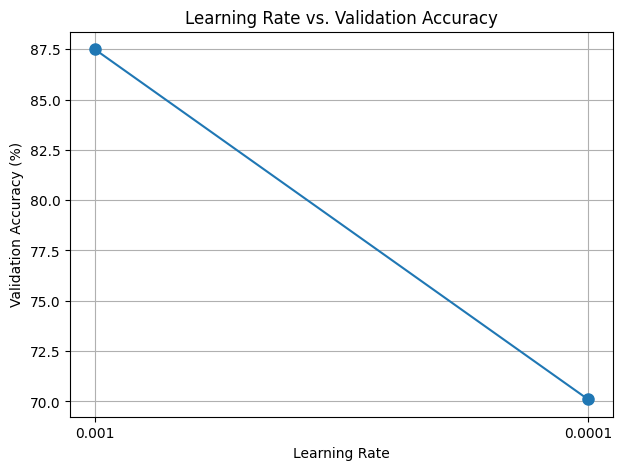

In [34]:
lr_values = [0.001, 0.0001]
lr_accs = [best_val_acc(sweep_results[f"lr_{lr}"]) for lr in lr_values]

plt.figure(figsize=(7, 5))
plt.plot([str(lr) for lr in lr_values], lr_accs, marker='o', linestyle='-', markersize=8)
plt.xlabel("Learning Rate")
plt.ylabel("Validation Accuracy (%)")
plt.title("Learning Rate vs. Validation Accuracy")
plt.grid(True)
plt.savefig("plot8_lr_vs_valacc.png", dpi=150, bbox_inches="tight")
plt.show()

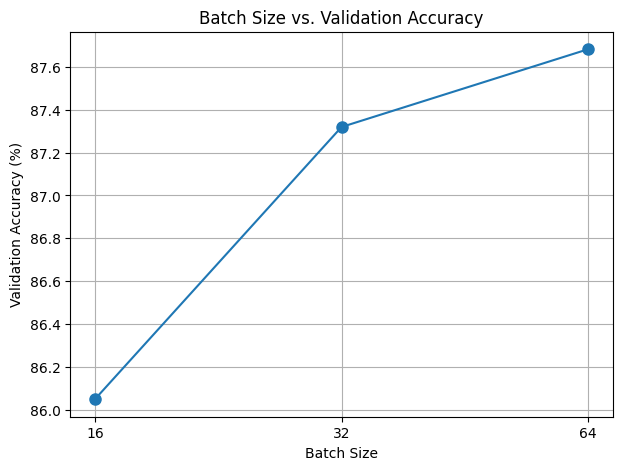

In [35]:
batch_values = [16, 32, 64]
batch_accs = [best_val_acc(sweep_results[f"batch_{bs}"]) for bs in batch_values]

plt.figure(figsize=(7, 5))
plt.plot([str(bs) for bs in batch_values], batch_accs, marker='o', linestyle='-', markersize=8)
plt.xlabel("Batch Size")
plt.ylabel("Validation Accuracy (%)")
plt.title("Batch Size vs. Validation Accuracy")
plt.grid(True)
plt.savefig("plot9_batch_vs_valacc.png", dpi=150, bbox_inches="tight")
plt.show()

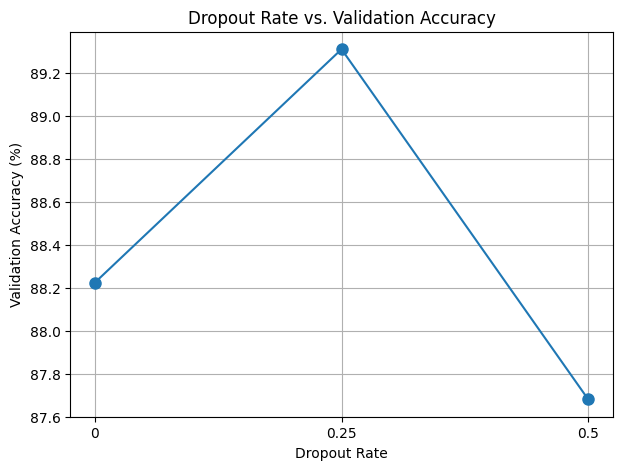

In [36]:
dropout_values = [0, 0.25, 0.5]
dropout_accs = [best_val_acc(sweep_results[f"dropout_{dr}"]) for dr in dropout_values]

plt.figure(figsize=(7, 5))
plt.plot([str(dr) for dr in dropout_values], dropout_accs, marker='o', linestyle='-', markersize=8)
plt.xlabel("Dropout Rate")
plt.ylabel("Validation Accuracy (%)")
plt.title("Dropout Rate vs. Validation Accuracy")
plt.grid(True)
plt.savefig("plot10_dropout_vs_valacc.png", dpi=150, bbox_inches="tight")
plt.show()

In [37]:
def build_case_a():
    model = mobilenet_v2(weights=MobileNet_V2_Weights.IMAGENET1K_V1)

    for param in model.features.parameters():
        param.requires_grad = False

    in_features = model.classifier[1].in_features
    head = nn.Linear(in_features, NUM_CLASSES)
    nn.init.kaiming_uniform_(head.weight, nonlinearity="relu")
    nn.init.zeros_(head.bias)
    model.classifier[1] = head

    return model

In [38]:
def build_case_b(unfreeze_last_n=3):
    model = mobilenet_v2(weights=MobileNet_V2_Weights.IMAGENET1K_V1)

    # Freeze everything first
    for param in model.features.parameters():
        param.requires_grad = False

    # Unfreeze only the last few feature blocks (upper/later layers)
    for param in model.features[-unfreeze_last_n:].parameters():
        param.requires_grad = True

    in_features = model.classifier[1].in_features
    head = nn.Linear(in_features, NUM_CLASSES)
    nn.init.kaiming_uniform_(head.weight, nonlinearity="relu")
    nn.init.zeros_(head.bias)
    model.classifier[1] = head

    return model

In [42]:
EPOCHS = 10

In [43]:
def train_transfer_case(case_name, model, head_lr=1e-3, fine_tune_lr=None):
    criterion = nn.CrossEntropyLoss()

    if case_name == "case_a":
        optimizer = optim.Adam(model.classifier[1].parameters(), lr=head_lr)
    else:
        optimizer = optim.Adam([
            {"params": model.classifier[1].parameters(), "lr": head_lr},
            {"params": [p for p in model.features.parameters() if p.requires_grad], "lr": fine_tune_lr},
        ])

    history = {"train_loss": [], "val_loss": [], "val_acc": []}
    for epoch in range(EPOCHS):
        model.train()
        running_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * images.size(0)
        history["train_loss"].append(running_loss / len(train_subset))

        model.eval()
        val_running_loss, correct, total = 0.0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(DEVICE), labels.to(DEVICE)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_running_loss += loss.item() * images.size(0)
                correct += (outputs.argmax(dim=1) == labels).sum().item()
                total += labels.size(0)
        history["val_loss"].append(val_running_loss / total)
        history["val_acc"].append(100.0 * correct / total)

        print(f"[{case_name}] Epoch {epoch+1}/{EPOCHS} | "
              f"Train Loss: {history['train_loss'][-1]:.4f} | "
              f"Val Loss: {history['val_loss'][-1]:.4f} | Val Acc: {history['val_acc'][-1]:.2f}%")

    return history

In [44]:
model_a = build_case_a().to(DEVICE)
history_a = train_transfer_case("case_a", model_a, head_lr=1e-3)

model_b = build_case_b(unfreeze_last_n=3).to(DEVICE)
history_b = train_transfer_case("case_b", model_b, head_lr=1e-3, fine_tune_lr=1e-5)

[case_a] Epoch 1/10 | Train Loss: 1.9329 | Val Loss: 0.8038 | Val Acc: 80.25%
[case_a] Epoch 2/10 | Train Loss: 0.6895 | Val Loss: 0.5311 | Val Acc: 86.05%
[case_a] Epoch 3/10 | Train Loss: 0.4845 | Val Loss: 0.4738 | Val Acc: 86.23%
[case_a] Epoch 4/10 | Train Loss: 0.3778 | Val Loss: 0.4200 | Val Acc: 87.14%
[case_a] Epoch 5/10 | Train Loss: 0.3180 | Val Loss: 0.3942 | Val Acc: 88.04%
[case_a] Epoch 6/10 | Train Loss: 0.2679 | Val Loss: 0.3841 | Val Acc: 87.50%
[case_a] Epoch 7/10 | Train Loss: 0.2364 | Val Loss: 0.3896 | Val Acc: 88.04%
[case_a] Epoch 8/10 | Train Loss: 0.2010 | Val Loss: 0.3508 | Val Acc: 87.50%
[case_a] Epoch 9/10 | Train Loss: 0.1798 | Val Loss: 0.3738 | Val Acc: 87.32%
[case_a] Epoch 10/10 | Train Loss: 0.1692 | Val Loss: 0.3460 | Val Acc: 87.86%
[case_b] Epoch 1/10 | Train Loss: 1.7581 | Val Loss: 0.6738 | Val Acc: 84.60%
[case_b] Epoch 2/10 | Train Loss: 0.5762 | Val Loss: 0.4654 | Val Acc: 85.69%
[case_b] Epoch 3/10 | Train Loss: 0.3869 | Val Loss: 0.4005 | V

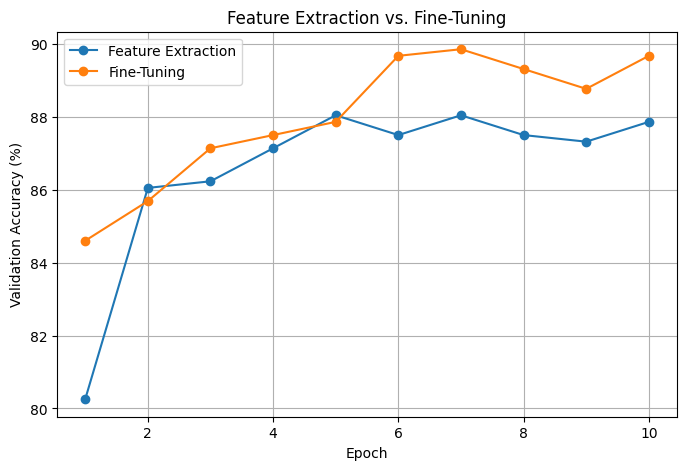

In [45]:
plt.figure(figsize=(8, 5))
epochs_range = range(1, EPOCHS + 1)
plt.plot(epochs_range, history_a["val_acc"], marker='o', label="Feature Extraction")
plt.plot(epochs_range, history_b["val_acc"], marker='o', label="Fine-Tuning")

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy (%)")
plt.title("Feature Extraction vs. Fine-Tuning")
plt.legend()
plt.grid(True)
plt.savefig("plot11_feature_extraction_vs_finetuning.png", dpi=150, bbox_inches="tight")
plt.show()

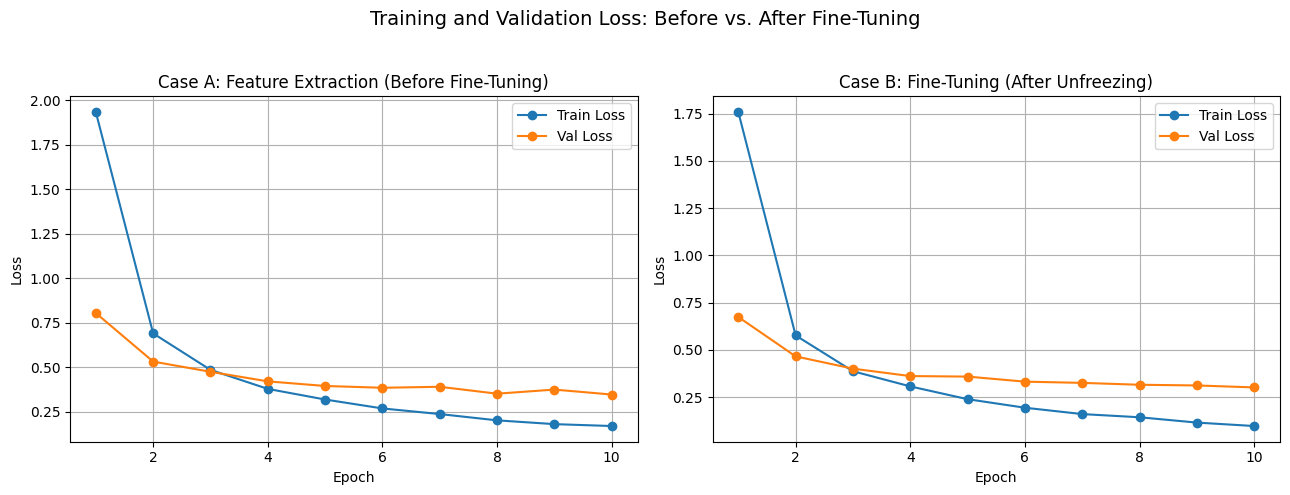

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(epochs_range, history_a["train_loss"], marker='o', label="Train Loss")
axes[0].plot(epochs_range, history_a["val_loss"], marker='o', label="Val Loss")
axes[0].set_title("Case A: Feature Extraction (Before Fine-Tuning)")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(epochs_range, history_b["train_loss"], marker='o', label="Train Loss")
axes[1].plot(epochs_range, history_b["val_loss"], marker='o', label="Val Loss")
axes[1].set_title("Case B: Fine-Tuning (After Unfreezing)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True)

fig.suptitle("Training and Validation Loss: Before vs. After Fine-Tuning", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("plot12_loss_before_after_finetuning.png", dpi=150, bbox_inches="tight")
plt.show()

In [47]:
candidate_configs = {
    "C1": {"lr": 0.001, "dropout": 0.25, "optimizer": "adam", "batch_size": 64},
    "C2": {"lr": 0.001, "dropout": 0.25, "optimizer": "momentum", "batch_size": 32},
    "C3": {"lr": 0.001, "dropout": 0,    "optimizer": "adam", "batch_size": 64},
    "C4": {"lr": 0.001, "dropout": 0.25, "optimizer": "adam", "batch_size": 32},
}

In [48]:
def build_and_train_fold(config, train_idx, val_idx, fold_num, tag):
    train_fold = torch.utils.data.Subset(full_dataset, train_idx)
    val_fold = torch.utils.data.Subset(full_dataset, val_idx)

    train_loader_fold = DataLoader(train_fold, batch_size=config["batch_size"], shuffle=True, num_workers=2)
    val_loader_fold = DataLoader(val_fold, batch_size=config["batch_size"], shuffle=False, num_workers=2)

    model = mobilenet_v2(weights=MobileNet_V2_Weights.IMAGENET1K_V1)
    for param in model.features.parameters():
        param.requires_grad = False

    in_features = model.classifier[1].in_features
    head = nn.Sequential(
        nn.Dropout(p=config["dropout"]),
        nn.Linear(in_features, NUM_CLASSES)
    )
    nn.init.kaiming_uniform_(head[1].weight, nonlinearity="relu")
    nn.init.zeros_(head[1].bias)
    model.classifier[1] = head
    model = model.to(DEVICE)

    criterion = nn.CrossEntropyLoss()

    if config["optimizer"] == "sgd":
        optimizer = optim.SGD(model.classifier[1].parameters(), lr=config["lr"])
    elif config["optimizer"] == "momentum":
        optimizer = optim.SGD(model.classifier[1].parameters(), lr=config["lr"], momentum=0.9)
    elif config["optimizer"] == "rmsprop":
        optimizer = optim.RMSprop(model.classifier[1].parameters(), lr=config["lr"])
    else:  # adam
        optimizer = optim.Adam(model.classifier[1].parameters(), lr=config["lr"])

    for epoch in range(EPOCHS):
        model.train()
        for images, labels in train_loader_fold:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(images), labels)
            loss.backward()
            optimizer.step()

    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in val_loader_fold:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            correct += (outputs.argmax(dim=1) == labels).sum().item()
            total += labels.size(0)
    fold_acc = 100.0 * correct / total

    print(f"[{tag}] Fold {fold_num}/5 | Val Acc: {fold_acc:.2f}%")
    return fold_acc

In [49]:
EPOCHS = 3  # keep CV epochs modest — this is already the longest cell in your notebook

In [50]:
from sklearn.model_selection import KFold
import numpy as np

kfold = KFold(n_splits=5, shuffle=True, random_state=42)
all_indices = np.arange(len(full_dataset))

cv_results = {}

for tag, config in candidate_configs.items():
    fold_accs = []
    for fold_num, (train_idx, val_idx) in enumerate(kfold.split(all_indices), start=1):
        acc = build_and_train_fold(config, train_idx, val_idx, fold_num, tag)
        fold_accs.append(acc)
    cv_results[tag] = fold_accs
    print(f"{tag} — Mean: {np.mean(fold_accs):.2f}% ± SD: {np.std(fold_accs):.2f}%\n")

[C1] Fold 1/5 | Val Acc: 85.73%
[C1] Fold 2/5 | Val Acc: 85.60%
[C1] Fold 3/5 | Val Acc: 86.68%
[C1] Fold 4/5 | Val Acc: 84.10%
[C1] Fold 5/5 | Val Acc: 85.87%
C1 — Mean: 85.60% ± SD: 0.84%

[C2] Fold 1/5 | Val Acc: 76.77%
[C2] Fold 2/5 | Val Acc: 79.35%
[C2] Fold 3/5 | Val Acc: 78.26%
[C2] Fold 4/5 | Val Acc: 74.73%
[C2] Fold 5/5 | Val Acc: 77.99%
C2 — Mean: 77.42% ± SD: 1.58%

[C3] Fold 1/5 | Val Acc: 83.02%
[C3] Fold 2/5 | Val Acc: 84.92%
[C3] Fold 3/5 | Val Acc: 87.23%
[C3] Fold 4/5 | Val Acc: 84.51%
[C3] Fold 5/5 | Val Acc: 87.09%
C3 — Mean: 85.35% ± SD: 1.61%

[C4] Fold 1/5 | Val Acc: 84.78%
[C4] Fold 2/5 | Val Acc: 86.55%
[C4] Fold 3/5 | Val Acc: 88.45%
[C4] Fold 4/5 | Val Acc: 84.78%
[C4] Fold 5/5 | Val Acc: 87.91%
C4 — Mean: 86.49% ± SD: 1.53%



In [51]:
print(f"{'Config':<8}{'F1':<8}{'F2':<8}{'F3':<8}{'F4':<8}{'F5':<8}{'Mean ± SD':<15}")
for tag, accs in cv_results.items():
    mean = np.mean(accs)
    sd = np.std(accs)
    fold_str = "".join(f"{a:<8.2f}" for a in accs)
    print(f"{tag:<8}{fold_str}{mean:.2f} ± {sd:.2f}")

Config  F1      F2      F3      F4      F5      Mean ± SD      
C1      85.73   85.60   86.68   84.10   85.87   85.60 ± 0.84
C2      76.77   79.35   78.26   74.73   77.99   77.42 ± 1.58
C3      83.02   84.92   87.23   84.51   87.09   85.35 ± 1.61
C4      84.78   86.55   88.45   84.78   87.91   86.49 ± 1.53


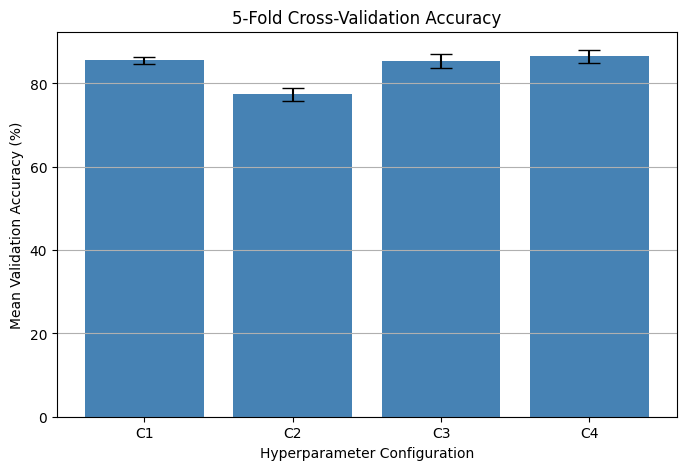

In [52]:
configs_list = list(cv_results.keys())
means = [np.mean(cv_results[c]) for c in configs_list]
sds = [np.std(cv_results[c]) for c in configs_list]

plt.figure(figsize=(8, 5))
plt.bar(configs_list, means, yerr=sds, capsize=8, color='steelblue')
plt.xlabel("Hyperparameter Configuration")
plt.ylabel("Mean Validation Accuracy (%)")
plt.title("5-Fold Cross-Validation Accuracy")
plt.grid(True, axis='y')
plt.savefig("plot13_kfold_cv.png", dpi=150, bbox_inches="tight")
plt.show()

In [53]:
import time

final_config = candidate_configs["C4"]  # {"lr":0.001,"dropout":0.25,"optimizer":"adam","batch_size":32}

def build_final_model(config):
    model = mobilenet_v2(weights=MobileNet_V2_Weights.IMAGENET1K_V1)
    for param in model.features.parameters():
        param.requires_grad = False

    in_features = model.classifier[1].in_features
    head = nn.Sequential(
        nn.Dropout(p=config["dropout"]),
        nn.Linear(in_features, NUM_CLASSES)
    )
    nn.init.kaiming_uniform_(head[1].weight, nonlinearity="relu")
    nn.init.zeros_(head[1].bias)
    model.classifier[1] = head
    return model

FINAL_EPOCHS = 10  # use a fuller budget now that this is your one final run

final_model = build_final_model(final_config).to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(final_model.classifier[1].parameters(), lr=final_config["lr"])

full_train_loader = DataLoader(full_dataset, batch_size=final_config["batch_size"], shuffle=True, num_workers=2)

start_time = time.time()

for epoch in range(FINAL_EPOCHS):
    final_model.train()
    running_loss = 0.0
    for images, labels in full_train_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = final_model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
    print(f"Epoch {epoch+1}/{FINAL_EPOCHS} | Train Loss: {running_loss/len(full_dataset):.4f}")

training_time = time.time() - start_time
print(f"\nTotal training time: {training_time:.2f} seconds")

Epoch 1/10 | Train Loss: 2.0429
Epoch 2/10 | Train Loss: 0.7564
Epoch 3/10 | Train Loss: 0.5531
Epoch 4/10 | Train Loss: 0.4511
Epoch 5/10 | Train Loss: 0.3770
Epoch 6/10 | Train Loss: 0.3382
Epoch 7/10 | Train Loss: 0.3174
Epoch 8/10 | Train Loss: 0.2769
Epoch 9/10 | Train Loss: 0.2523
Epoch 10/10 | Train Loss: 0.2310

Total training time: 170.48 seconds


In [54]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

final_model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        outputs = final_model(images)
        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_accuracy = accuracy_score(all_labels, all_preds) * 100
precision = precision_score(all_labels, all_preds, average='macro', zero_division=0) * 100
recall = recall_score(all_labels, all_preds, average='macro', zero_division=0) * 100
f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0) * 100

num_params = sum(p.numel() for p in final_model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in final_model.parameters())

mean_cv_acc = np.mean(cv_results["C4"])
cv_sd = np.std(cv_results["C4"])

print(f"{'Metric':<25}{'Value'}")
print(f"{'Mean CV Accuracy':<25}{mean_cv_acc:.2f}%")
print(f"{'CV Standard Deviation':<25}{cv_sd:.2f}")
print(f"{'Test Accuracy':<25}{test_accuracy:.2f}%")
print(f"{'Precision':<25}{precision:.2f}%")
print(f"{'Recall':<25}{recall:.2f}%")
print(f"{'F1-score':<25}{f1:.2f}%")
print(f"{'Training Time':<25}{training_time:.2f} sec")
print(f"{'Trainable Parameters':<25}{num_params:,}")
print(f"{'Total Parameters':<25}{total_params:,}")

Metric                   Value
Mean CV Accuracy         86.49%
CV Standard Deviation    1.53
Test Accuracy            87.52%
Precision                87.63%
Recall                   87.43%
F1-score                 87.30%
Training Time            170.48 sec
Trainable Parameters     47,397
Total Parameters         2,271,269


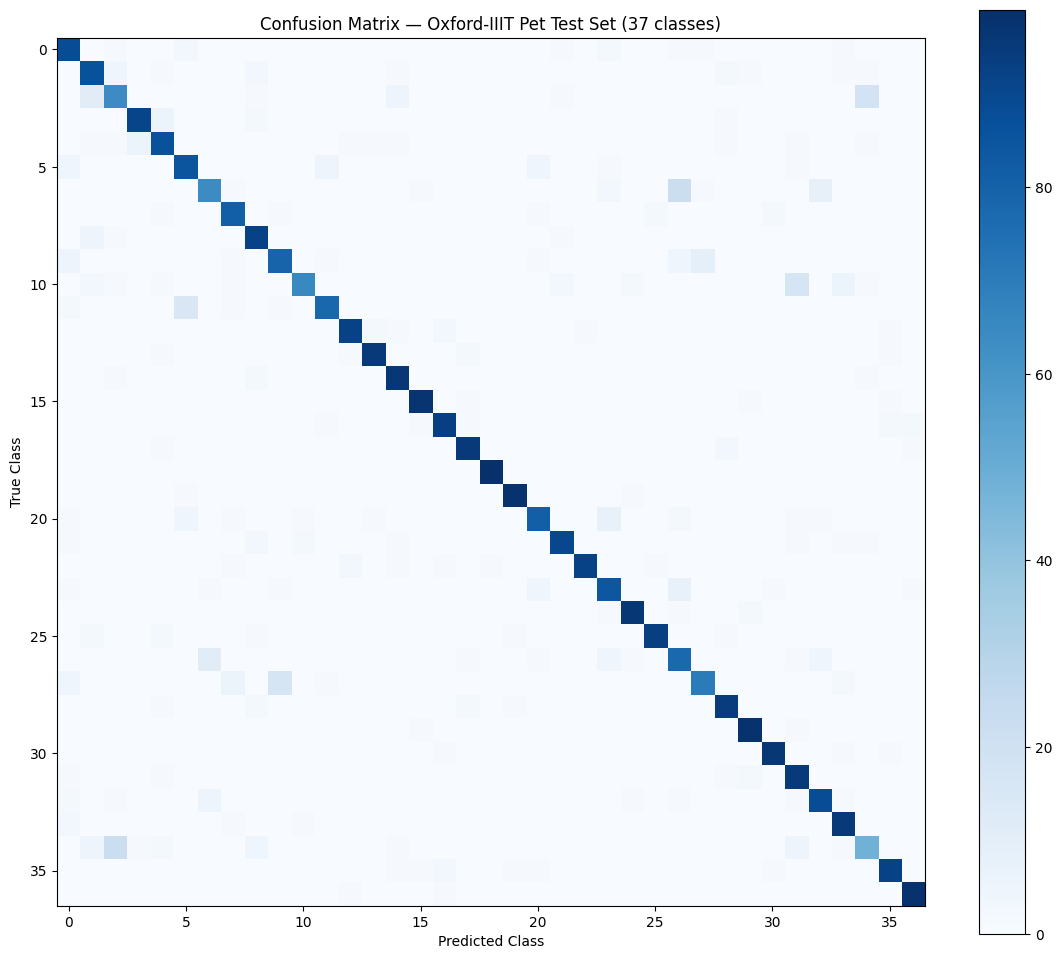

Best classified classes:
  Keeshond: 100.0%
  Samoyed: 98.0%
  Leonberger: 98.0%
  Yorkshire Terrier: 98.0%
  Great Pyrenees: 97.0%

Most confused (worst) classes:
  Staffordshire Bull Terrier: 53.9%
  American Pit Bull Terrier: 64.0%
  Birman: 64.0%
  Chihuahua: 65.0%
  Russian Blue: 70.0%

Most frequent confusion: true='Birman' predicted='Ragdoll' (22 times)


In [55]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(14, 12))
plt.imshow(cm, cmap='Blues')
plt.colorbar()
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title("Confusion Matrix — Oxford-IIIT Pet Test Set (37 classes)")
plt.savefig("plot14_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

# Identify best-classified and most-confused classes
class_names = full_dataset.classes if hasattr(full_dataset, "classes") else [str(i) for i in range(NUM_CLASSES)]

per_class_acc = cm.diagonal() / cm.sum(axis=1)
best_classes = np.argsort(per_class_acc)[-5:][::-1]
worst_classes = np.argsort(per_class_acc)[:5]

print("Best classified classes:")
for idx in best_classes:
    print(f"  {class_names[idx]}: {per_class_acc[idx]*100:.1f}%")

print("\nMost confused (worst) classes:")
for idx in worst_classes:
    print(f"  {class_names[idx]}: {per_class_acc[idx]*100:.1f}%")

# Find the single most common confusion pair (excluding diagonal)
cm_no_diag = cm.copy()
np.fill_diagonal(cm_no_diag, 0)
most_confused_idx = np.unravel_index(np.argmax(cm_no_diag), cm_no_diag.shape)
print(f"\nMost frequent confusion: true='{class_names[most_confused_idx[0]]}' "
      f"predicted='{class_names[most_confused_idx[1]]}' ({cm_no_diag[most_confused_idx]} times)")

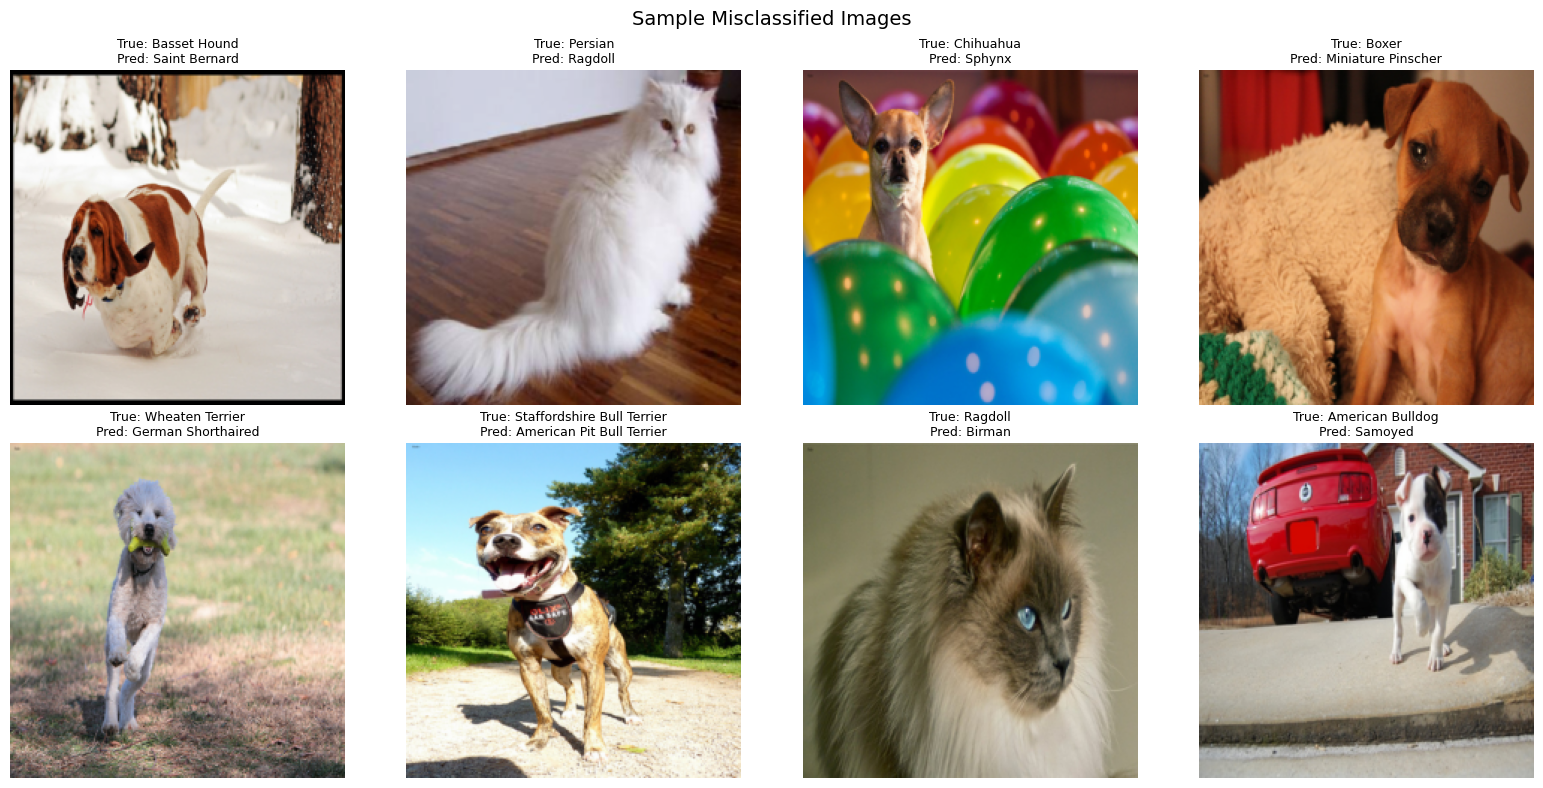

In [56]:
misclassified_idx = [i for i, (p, l) in enumerate(zip(all_preds, all_labels)) if p != l]
sample_idx = np.random.choice(misclassified_idx, size=min(8, len(misclassified_idx)), replace=False)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for ax, idx in zip(axes, sample_idx):
    image, true_label = test_dataset[idx]
    # Undo normalization for display
    img_display = image.permute(1, 2, 0).numpy()
    img_display = img_display * np.array(IMAGENET_STD) + np.array(IMAGENET_MEAN)
    img_display = np.clip(img_display, 0, 1)

    pred_label = all_preds[idx]
    ax.imshow(img_display)
    ax.set_title(f"True: {class_names[true_label]}\nPred: {class_names[pred_label]}", fontsize=9)
    ax.axis('off')

plt.suptitle("Sample Misclassified Images", fontsize=14)
plt.tight_layout()
plt.savefig("plot15_misclassified.png", dpi=150, bbox_inches="tight")
plt.show()

In [57]:
summary_table = {
    "Baseline":            {"val_acc": max(results["zero"]["val_acc"]),        "cv_acc": None, "cv_sd": None, "test_acc": None, "train_time": None},
    "Best Initialization": {"val_acc": max(max(results[m]["val_acc"]) for m in results),        "cv_acc": None, "cv_sd": None, "test_acc": None, "train_time": None},
    "Best Regularization": {"val_acc": max(max(reg_results[m]["val_acc"]) for m in reg_results), "cv_acc": None, "cv_sd": None, "test_acc": None, "train_time": None},
    "Best Optimizer":      {"val_acc": max(max(opt_results[m]["val_acc"]) for m in opt_results), "cv_acc": None, "cv_sd": None, "test_acc": None, "train_time": None},
    "Best Hyperparameters":{"val_acc": max(max(sweep_results[m]["val_acc"]) for m in sweep_results), "cv_acc": None, "cv_sd": None, "test_acc": None, "train_time": None},
    "Fine-Tuned Model":    {"val_acc": max(history_b["val_acc"]),              "cv_acc": None, "cv_sd": None, "test_acc": None, "train_time": None},
    "Final Model (C4)":    {"val_acc": None, "cv_acc": mean_cv_acc, "cv_sd": cv_sd, "test_acc": test_accuracy, "train_time": training_time},
}

print(f"{'Configuration':<22}{'CV Accuracy':<14}{'SD':<10}{'Test Accuracy':<16}{'Training Time':<15}")
for name, row in summary_table.items():
    cv_str = f"{row['cv_acc']:.2f}%" if row['cv_acc'] is not None else (f"{row['val_acc']:.2f}%*" if row['val_acc'] is not None else "—")
    sd_str = f"{row['cv_sd']:.2f}" if row['cv_sd'] is not None else "—"
    test_str = f"{row['test_acc']:.2f}%" if row['test_acc'] is not None else "—"
    time_str = f"{row['train_time']:.1f}s" if row['train_time'] is not None else "—"
    print(f"{name:<22}{cv_str:<14}{sd_str:<10}{test_str:<16}{time_str:<15}")

print("\n* = best validation accuracy (single split), not cross-validated — CV/test reserved for final model only")

Configuration         CV Accuracy   SD        Test Accuracy   Training Time  
Baseline              88.77%*       —         —               —              
Best Initialization   89.49%*       —         —               —              
Best Regularization   89.67%*       —         —               —              
Best Optimizer        88.77%*       —         —               —              
Best Hyperparameters  89.49%*       —         —               —              
Fine-Tuned Model      89.86%*       —         —               —              
Final Model (C4)      86.49%        1.53      87.52%          170.5s         

* = best validation accuracy (single split), not cross-validated — CV/test reserved for final model only
